# 02 · GAT-style edge attention

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/02_gat_attention.ipynb)

This notebook looks at `hmb_kuramoto_ode.models.attention.EdgeAttention`,
the learned-weighting ingredient used both by the GAT baseline and inside
the full model's continuous vector field. For every directed edge `(src,
dst)` it scores `[h_src, h_dst, edge_weight]` with a small MLP and then
applies a **segment softmax**: scores are normalized separately for each
destination node, so the incoming edge weights of any node always sum to 1
— exactly like standard graph attention (GAT), restricted to a node's
actual graph neighbors rather than the whole graph.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


In [2]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph, SPATIAL_SAME_BAND, CROSS_FREQUENCY_LOCAL
from hmb_kuramoto_ode.models.attention import EdgeAttention

seed_everything(7)
REGIONS = 4
edge_index, edge_types = build_hierarchical_graph(REGIONS)
num_nodes = REGIONS * 5
hidden = 8

attention = EdgeAttention(hidden)
h = torch.randn(num_nodes, hidden)
alpha = attention(h, edge_index)
print(f"{alpha.shape[0]} edge weights, one per directed edge")

# Segment softmax: weights of edges pointing INTO the same destination node sum to 1.
dst = edge_index[1]
incoming_sums = torch.zeros(num_nodes).index_add_(0, dst, alpha)
print("max deviation of per-node incoming weights from 1.0:", (incoming_sums - 1).abs().max().item())


110 edge weights, one per directed edge
max deviation of per-node incoming weights from 1.0: 1.1920928955078125e-07


## Training attention on a toy classification task

To see attention specialize, we train a tiny two-layer edge-attention
classifier (the same building block as `GATClassifier` in
`examples/stew_real_experiment.py`, just smaller) on a synthetic task: two
classes of graph samples, where class 1 carries a stronger, alpha-band
signal. If attention is doing its job, the edges touching the alpha-band
nodes should end up weighted differently from the rest once training
finishes.

In [3]:
class TinyGAT(nn.Module):
    """Two-layer edge-attention network over flattened rhythm nodes."""
    def __init__(self, edge_index, features, hidden=16, classes=2):
        super().__init__()
        self.register_buffer("edge_index", edge_index)
        self.input = nn.Linear(features, hidden)
        self.attn1 = EdgeAttention(hidden)
        self.proj1 = nn.Linear(hidden, hidden)
        self.attn2 = EdgeAttention(hidden)
        self.proj2 = nn.Linear(hidden, hidden)
        self.head = nn.Linear(hidden, classes)

    def layer(self, h, attn, proj):
        src, dst = self.edge_index
        alpha = attn(h, self.edge_index)
        out = torch.zeros_like(h)
        out.index_add_(0, dst, alpha[:, None] * proj(h[src]))
        return torch.relu(out + h)

    def forward(self, x):
        batch, nodes, _ = x.shape
        h = torch.relu(self.input(x.reshape(-1, x.shape[-1])))
        h = self.layer(h, self.attn1, self.proj1)
        h = self.layer(h, self.attn2, self.proj2)
        return self.head(h.reshape(batch, nodes, -1).mean(1))


In [4]:
FEATURES = 6  # mirrors the 6 real rhythm features (log/relative power, amplitude, phase sin/cos, entropy)
ALPHA_BAND_NODES = torch.arange(2, num_nodes, 5)  # node index 2, 7, 12, ... is the alpha rhythm of each electrode


def synthetic_batch(n, seed):
    g = torch.Generator().manual_seed(seed)
    labels = torch.randint(0, 2, (n,), generator=g)
    x = torch.randn(n, num_nodes, FEATURES, generator=g) * 0.5
    x[:, ALPHA_BAND_NODES, :] += labels.float()[:, None, None] * 1.5
    return x, labels


xtr, ytr = synthetic_batch(128, seed=1)
xval, yval = synthetic_batch(32, seed=2)

model = TinyGAT(edge_index, FEATURES, hidden=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)


def mean_attention_by_type(model, x):
    with torch.no_grad():
        h = torch.relu(model.input(x.reshape(-1, x.shape[-1])))
        alpha = model.attn1(h, model.edge_index)
    return {
        "same-band spatial": float(alpha[edge_types == SPATIAL_SAME_BAND].mean()),
        "cross-frequency local": float(alpha[edge_types == CROSS_FREQUENCY_LOCAL].mean()),
    }


before = mean_attention_by_type(model, xtr)
history = []
for epoch in range(60):
    model.train()
    optimizer.zero_grad()
    logits = model(xtr)
    loss = nn.functional.cross_entropy(logits, ytr)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        val_acc = (model(xval).argmax(1) == yval).float().mean()
    history.append({"epoch": epoch, "loss": loss.item(), "val_accuracy": float(val_acc)})
after = mean_attention_by_type(model, xtr)

print("mean attention weight by edge type")
print(f"  before training: {before}")
print(f"  after training:  {after}")


mean attention weight by edge type
  before training: {'same-band spatial': 0.17767734825611115, 'cross-frequency local': 0.18337100744247437}
  after training:  {'same-band spatial': 0.14943371713161469, 'cross-frequency local': 0.19396236538887024}


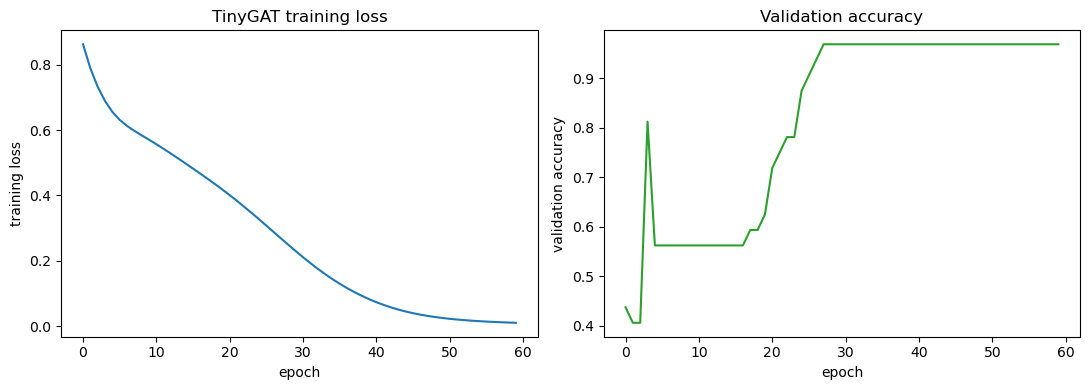

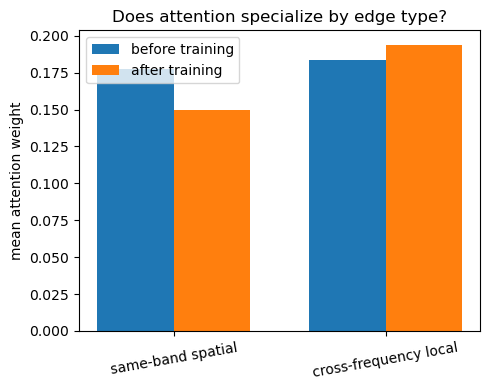

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs = [h["epoch"] for h in history]
axes[0].plot(epochs, [h["loss"] for h in history])
axes[0].set(xlabel="epoch", ylabel="training loss", title="TinyGAT training loss")
axes[1].plot(epochs, [h["val_accuracy"] for h in history], color="tab:green")
axes[1].set(xlabel="epoch", ylabel="validation accuracy", title="Validation accuracy")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
labels = list(before.keys())
xpos = np.arange(len(labels))
ax.bar(xpos - 0.18, [before[l] for l in labels], width=0.36, label="before training")
ax.bar(xpos + 0.18, [after[l] for l in labels], width=0.36, label="after training")
ax.set_xticks(xpos); ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel("mean attention weight")
ax.set_title("Does attention specialize by edge type?")
ax.legend()
fig.tight_layout()
plt.show()


## Key takeaway

Segment softmax gives every node a proper probability distribution over its
own neighbors, and — unlike the fixed mean aggregation in notebook 01 — that
distribution is *learned* to fit the task. The same `EdgeAttention` module
reappears unchanged inside `KuramotoGrandVectorField` (notebooks 03-06),
where it weights both the diffusion term and the phase-coupling term.